# Notebook Statapp

# Phishing emails classifier

## Librairies

In [1]:
# Libraries Installation
# !pip install kagglehub
# !pip install wordcloud 
# !pip install seaborn
# !pip install textblob
# !pip install datasets
# !pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 53.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.2.0
    Uninstalling fsspec-2025.2.0:
      Successfully uninstalled fsspec-2025.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
s3fs 2025.2.0 requires fsspec==2025.2.0.*, but you have fsspec 2024.12.0 which is incompatible.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import kagglehub
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import unicodedata
from sklearn.naive_bayes import MultinomialNB
from nltk.tokenize import word_tokenize
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
import pickle
tqdm.pandas()

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Classifier data

https://huggingface.co/datasets/SetFit/enron_spam

In [3]:
from datasets import load_dataset

df = load_dataset("SetFit/enron_spam")

# To avoid rewriting code for previous version
df=pd.concat([df["train"].to_pandas(),df["test"].to_pandas()])

df.sample(n=10)

Repo card metadata block was not found. Setting CardData to empty.


,message_id,text,label,label_text,subject,message,date
15301,33450,extra time - cures premature ejaculation hello...,1,spam,extra time - cures premature ejaculation,"hello ,\ndid you ejaculate before or within a ...",2005-07-08
11689,16388,extra time did you ejaculate before or within ...,1,spam,extra time,did you ejaculate before or within a few minut...,2005-06-26
20368,13352,enron mentions enron cuts shareholder equity b...,0,ham,enron mentions,enron cuts shareholder equity by 1 . 2 bln usd...,2001-10-18
1771,22266,"goldeditor : "" buy in may and go away "" - expl...",1,spam,"goldeditor : "" buy in may and go away "" - expl...",www . goldeditor . com\nbuy in may and go away...,2005-07-13
1285,19013,if you are paying more than 3 . 6 % on your mo...,1,spam,,if you are paying more than 3 . 6 % on your mo...,2004-05-26
23679,29237,save 70 percent on super viagra 245610 save 70...,1,spam,save 70 percent on super viagra 245610,save 70 percent on super viagra and increase s...,2004-08-02
687,2052,duke energy field 9 / 00 please add the demand...,0,ham,duke energy field 9 / 00,please add the demand charge for excess fees f...,2000-11-16
2567,16809,total transfer capabilities due to caiso roll ...,0,ham,total transfer capabilities,due to caiso roll out of the new web based oas...,2001-07-09
23804,22549,global risk management operations recognizing ...,0,ham,global risk management operations,"recognizing enron  , s increasing worldwide p...",2000-01-17
28454,2641,noms / actual flow for 2 / 26 we agree\n- - - ...,0,ham,noms / actual flow for 2 / 26,we agree\n- - - - - - - - - - - - - - - - - - ...,2001-02-27


In [4]:
df.rename(columns={"text":"body"},inplace=True)
original_df=df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33716 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   message_id  33716 non-null  int64        
 1   body        33716 non-null  object       
 2   label       33716 non-null  int64        
 3   label_text  33716 non-null  object       
 4   subject     33716 non-null  object       
 5   message     33716 non-null  object       
 6   date        33716 non-null  datetime64[s]
dtypes: datetime64[s](1), int64(2), object(4)
memory usage: 2.1+ MB


Saving data

In [5]:
#!mkdir data
#df.to_csv("enron_data.csv")
#!mv enron_data.csv data


Counting fake vs true

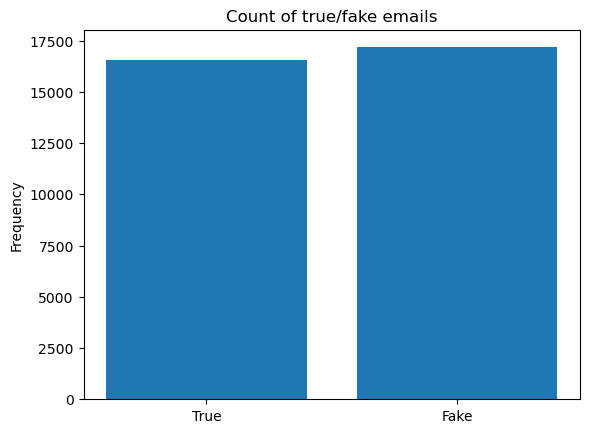

In [6]:
plt.hist(df.loc[:,'label'], bins=[-0.5,0.5,1.5] ,rwidth=0.8)
plt.xticks([0,1],['True','Fake'])
plt.ylabel("Frequency")
plt.title("Count of true/fake emails")
plt.show()

Balanced Dataset

## Data preprocessing

### Cleaning

In [7]:



def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    try:
        text = unicodedata.normalize("NFKC", text)  # Normalize characters
    except:
        print(text)
        return
    text = str(text).lower()
    sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
    for sequence in sequences:
        text=re.sub(sequence,'',text)
    
    return text

<>:10: SyntaxWarning: invalid escape sequence '\['
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\['
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_15518/3587267797.py:10: SyntaxWarning: invalid escape sequence '\['
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/tmp/ipykernel_15518/3587267797.py:10: SyntaxWarning: invalid escape sequence '\S'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/tmp/ipykernel_15518/3587267797.py:10: SyntaxWarning: invalid escape sequence '\w'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']


In [8]:
df['body']=df['body'].apply(clean_text)

In [9]:
df.sample(n=10)['body']

21528    re  wallium wiagra ciallis hello  would you li...
27115    cheapest cia  lis on the internet  sa  ve     ...
17281    team  ken it seems that there may be an intern...
1847     re  netco legal transition plan tammie schoppe...
1434     re  project tracking database access hi sandy ...
23151    are you ready to get it  hello viagra is the  ...
30451    windows xp and office xp for    infinite chapm...
11648    looking for a perfect gift  get a rolex       ...
27687    re  may  nomination george the following are m...
14262    hi again people observe  ship street  right  p...
Name: body, dtype: object

#### Stopwords + Lemmatization

In [10]:
#Téléchargement des ressources nécessaires
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

In [11]:
sw=set(stopwords.words('english') + ['hou','ect'])
lemmatizer = WordNetLemmatizer()


def stop_lem(text):
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split(' '))

df['body']=df['body'].progress_apply(stop_lem)

100%|██████████| 33716/33716 [00:24<00:00, 1363.05it/s]


In [12]:
df.sample(n=10)["body"]

22142    meeting follow louise enjoyed meeting week ql ...
24554     transwestern response ferc data request  usgt...
20422    http    www  blomqvist  org hello visited www ...
2253     cornhusker contact information lone star pipel...
11351    email lottrey  desk lotto chancellor internati...
31314    fw  csfb independent power weekly  note eei in...
27350     know get search engine result  submitting web...
2572      like girl loose goodbyeedition crumplebackhan...
10712    onlinepharmacycheap sergio hoffmann     psycho...
13464    shut  meter  meter  tri  c resource gov  danie...
Name: body, dtype: object

Helper function for future texts

In [13]:
def preprocessing(text):
    return stop_lem(clean_text(text))
    
preprocessing("Ronaldo began his senior career with Sporting CP, before signing with Manchester United in 2003, winning the FA Cup in his first season. He went on to win three consecutive Premier League titles, the Champions League and the FIFA Club World Cup; at age 23, he won his first Ballon d'Or.")

'ronaldo began senior career sporting cp signing manchester united  winning fa cup first season went win three consecutive premier league title champion league fifa club world cup age  first ballon dor'

To make data manipulation easier

In [14]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

## Descriptive statistics/visualisations

### Wordclouds

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

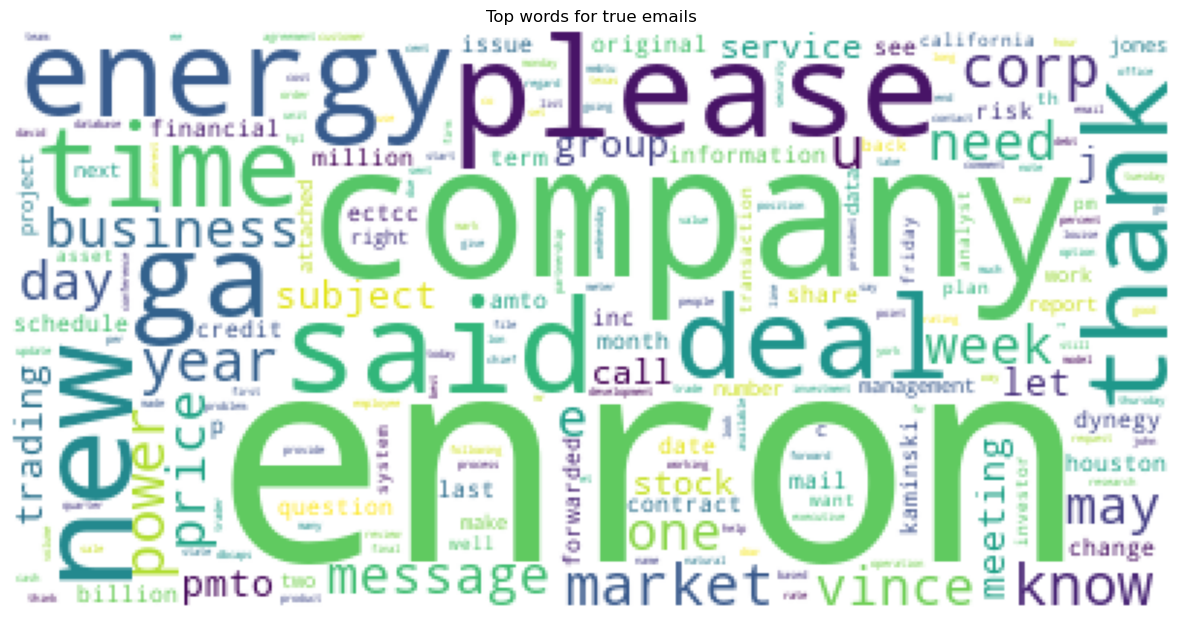

In [15]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in true_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for true emails')
plt.imshow(wc)
plt.axis("off")

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

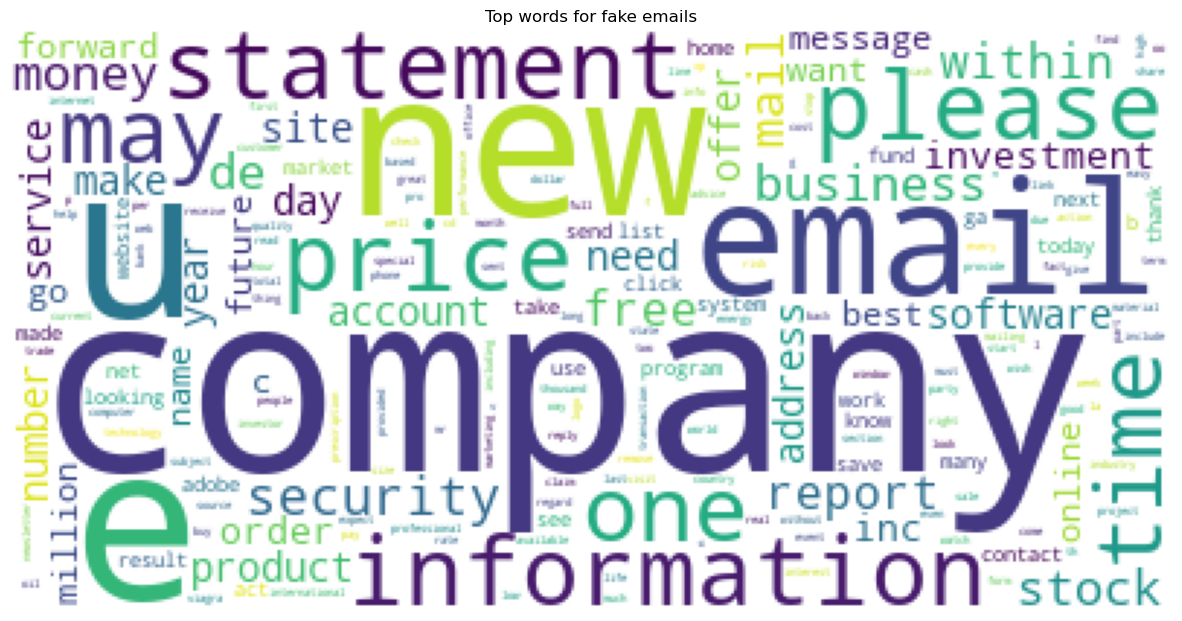

In [16]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in fake_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for fake emails')
plt.imshow(wc)
plt.axis("off")

100%|██████████| 17171/17171 [00:00<00:00, 1041780.85it/s]


Text(0.5, 1.0, 'KDE plot')

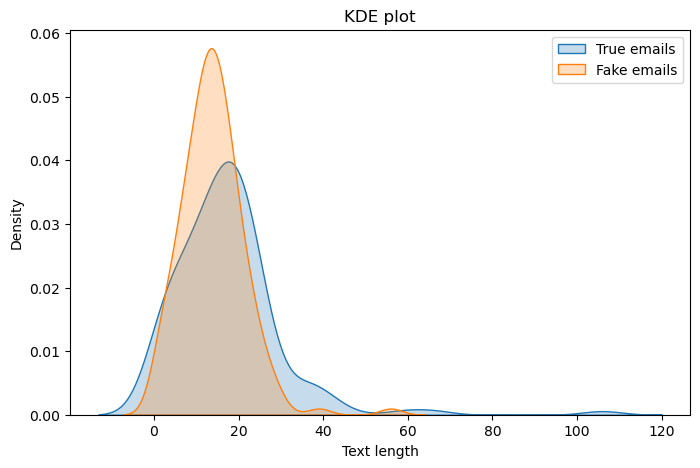

In [17]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='True emails')  
sns.kdeplot(fake_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Text length")
plt.ylabel("Density")
plt.title("KDE plot")


### Zipf law

Dictionaries with word counts

In [18]:
def count_dict(data):
    words=''.join(text for text in data['body']).split(' ')
    word_counts={}
    for word in tqdm((words)):
        word_counts[word]=word_counts.get(word,0) + 1
    word_counts.pop('')
    s=sum(word_counts.values())
    return {k:v/s for k,v in word_counts.items()}
true_word_count=count_dict(true_df)
fake_word_count=count_dict(fake_df)

100%|██████████| 2979508/2979508 [00:00<00:00, 3191152.67it/s]


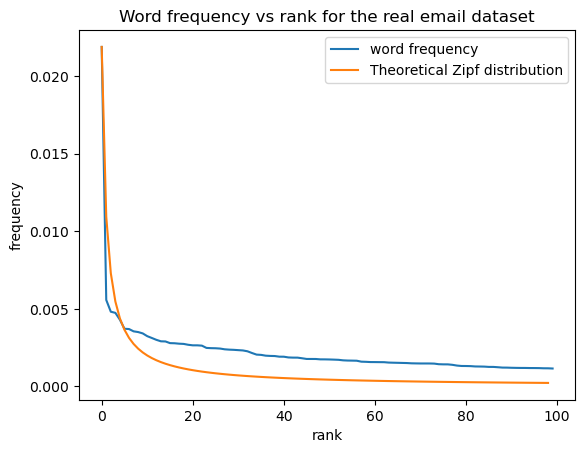

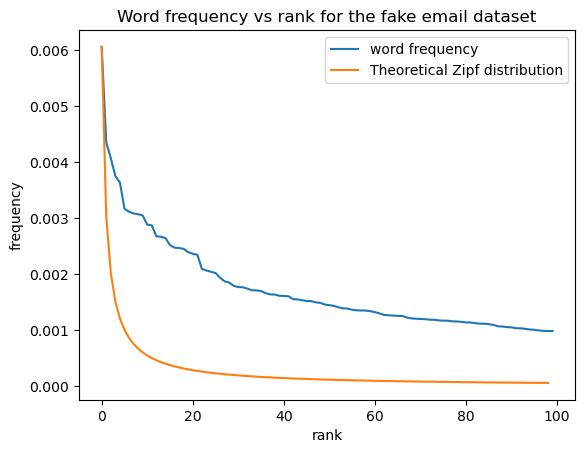

In [19]:

plt.plot(list(sorted(true_word_count.values(),reverse=True))[:100],label='word frequency')
plt.plot([max(list(true_word_count.values()))/(x) for x in np.arange(100)[1:]],label='Theoretical Zipf distribution')
plt.ylabel('frequency')
plt.xlabel('rank')
plt.title('Word frequency vs rank for the real email dataset')
plt.legend()
plt.show()
plt.plot(list(sorted(fake_word_count.values(),reverse=True))[:100],label='word frequency')
plt.plot([max(list(fake_word_count.values()))/x for x in np.arange(100)[1:]],label='Theoretical Zipf distribution')
plt.ylabel('frequency')
plt.xlabel('rank')
plt.title('Word frequency vs rank for the fake email dataset')
plt.legend()

We observe that the word frequency curve for the real email dataset fits the theoretical zipf distribution way more than the fake email dataset

### Sentiment Analysis

In [20]:

def gen_sentiment(df,col):
    def pol(x):
        try:
            return TextBlob(x).sentiment.polarity
        except:
            return x
    def sub(x):
        try:
            return TextBlob(x).sentiment.subjectivity
        except:
            return x


    df["polarity"]=df[col].progress_apply(pol)
    df["subjectivity"]=df[col].progress_apply(sub)
    
    
gen_sentiment(true_df,'subject')
gen_sentiment(fake_df,'subject')


100%|██████████| 16545/16545 [00:02<00:00, 6958.67it/s]
/tmp/ipykernel_15518/1947804801.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["polarity"]=df[col].progress_apply(pol)
100%|██████████| 16545/16545 [00:02<00:00, 7511.63it/s]
/tmp/ipykernel_15518/1947804801.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["subjectivity"]=df[col].progress_apply(sub)
100%|██████████| 17171/17171 [00:02<00:00, 6846.23it/s]
/tmp/ipykernel_15518/1947804801.py:14: SettingWithCopyWarning: 
A value is trying to

Text(0.5, 1.0, 'Density estimation of subjectivity')

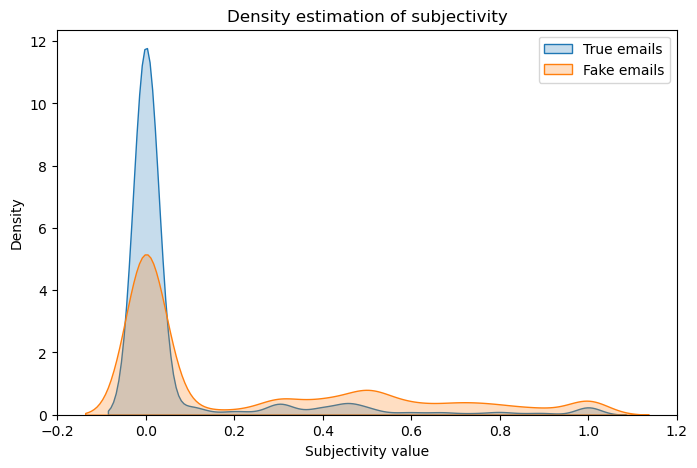

In [21]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['subjectivity'],fill=True,label='True emails')  
sns.kdeplot(fake_df['subjectivity'], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Subjectivity value")
plt.ylabel("Density")
plt.title("Density estimation of subjectivity")


Text(0.5, 1.0, 'Density estimation of polarity')

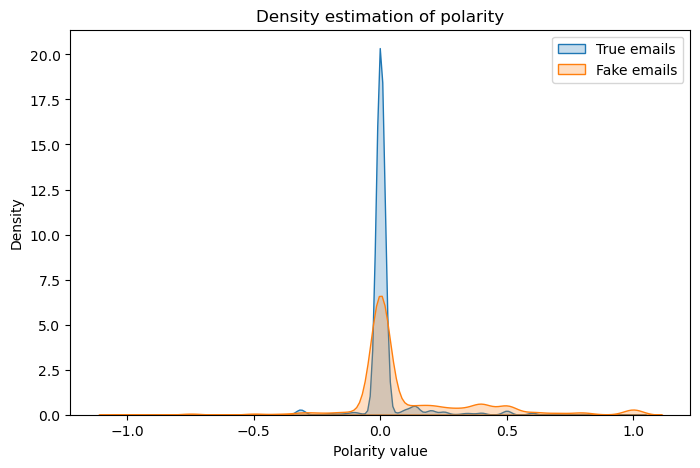

In [22]:

plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['polarity'],fill=True,label='True emails')  
sns.kdeplot(fake_df['polarity'], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Polarity value")
plt.ylabel("Density")
plt.title("Density estimation of polarity")


We see that sentiment distributions for real emails seem to be way closer to the mean value (neutral value) than for fake emails

In [23]:
original_df

,message_id,body,label,label_text,subject,message,date
0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13
...,...,...,...,...,...,...,...
1995,6578,re : book notes vince : look forward to meetin...,0,ham,re : book notes,vince : look forward to meeting you . . .\namy...,2000-07-26
1996,128,rollout schedule for unify real - time deal / ...,0,ham,rollout schedule for unify real - time deal / ...,a walk - thru / demo of this new functionality...,2000-01-11
1997,8485,anshuman shrivastava sandeep : vince has asked...,0,ham,anshuman shrivastava,sandeep : vince has asked me to coordinate wit...,2001-02-06
1998,7311,"re : good morning john ,\ni shall see christie...",0,ham,re : good morning,"john ,\ni shall see christie tomorrow and i sh...",2000-10-18


In [24]:
df

,message_id,body,label,label_text,subject,message,date
0,33214,software understanding oem softwarelead t...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,11929,perspective ferc regulatory action client conf...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,19784,wanted try ci li thought way expensive viagr...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,2209,enron hpl actuals december teco tap en...,0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,15880,looking cheap high quality software rotated ...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13
...,...,...,...,...,...,...,...
1995,6578,book note vince look forward meeting amyvi...,0,ham,re : book notes,vince : look forward to meeting you . . .\namy...,2000-07-26
1996,128,rollout schedule unify real time deal path u...,0,ham,rollout schedule for unify real - time deal / ...,a walk - thru / demo of this new functionality...,2000-01-11
1997,8485,anshuman shrivastava sandeep vince asked coor...,0,ham,anshuman shrivastava,sandeep : vince has asked me to coordinate wit...,2001-02-06
1998,7311,good morning john shall see christie tomorrow...,0,ham,re : good morning,"john ,\ni shall see christie tomorrow and i sh...",2000-10-18


### Hyperlink count 

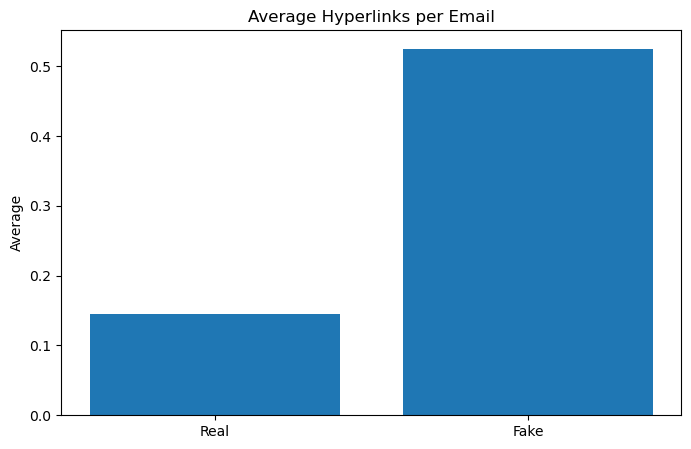

In [25]:

def count_hyperlinks(text):
    return len(re.findall(r'http+', text))

def count_attachments(text):
    return len(re.findall(r'attachment|file|pdf|image|zip|doc', text, re.IGNORECASE))


df["hyperlink_count"] = original_df["body"].apply(count_hyperlinks)


fig, ax = plt.subplots(1, 1, figsize=(8, 5))


ax.bar(["Real", "Fake"], df.groupby("label")["hyperlink_count"].mean())
ax.set_title("Average Hyperlinks per Email")
ax.set_ylabel("Average")

plt.show()

### Email time period 

On month

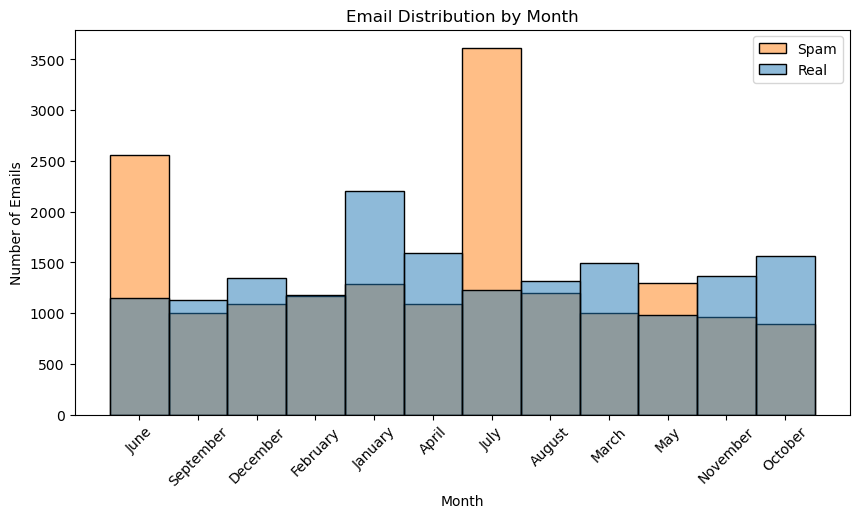

In [26]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.month_name()

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="month", bins=12, hue=df["label"],discrete=True)


plt.xlabel("Month")
plt.ylabel("Number of Emails")
plt.title("Email Distribution by Month")
plt.legend(labels=["Spam","Real"])
plt.xticks(rotation=45) 

plt.show()

On day in the month

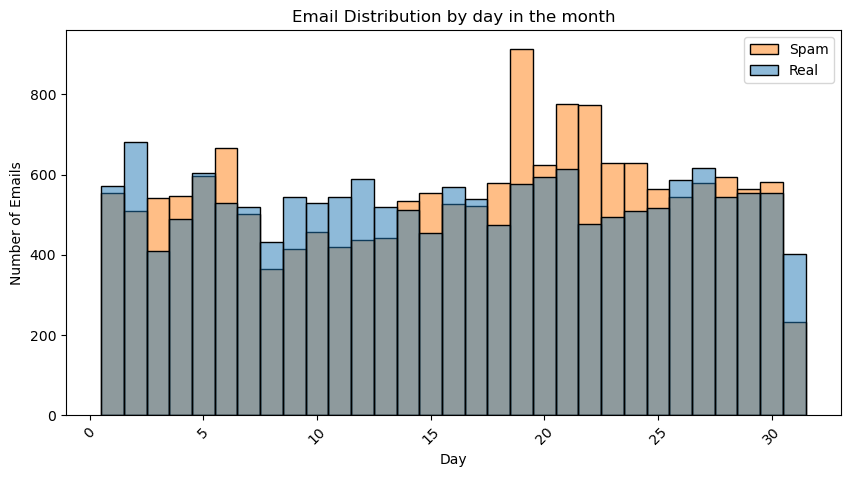

In [27]:
df["month_day"] = df["date"].apply(lambda x:x.day)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="month_day", bins=31, hue=df["label"],discrete=True)


plt.xlabel("Day")
plt.ylabel("Number of Emails")
plt.title("Email Distribution by day in the month")
plt.legend(labels=["Spam","Real"])
plt.xticks(rotation=45) 

plt.show()

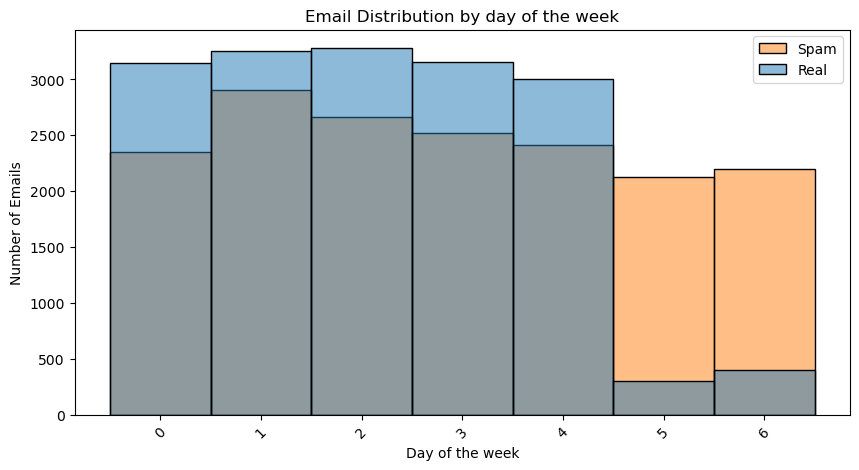

In [28]:
df["weekday"] = df["date"].apply(lambda x:x.weekday())

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="weekday", bins=31, hue=df["label"],discrete=True)


plt.xlabel("Day of the week")

plt.ylabel("Number of Emails")
plt.title("Email Distribution by day of the week")
plt.xticks(rotation=45) 
plt.legend(labels=["Spam","Real"])

plt.show()

0: Monday, 6:Saturday

# Model

## Count vector encoding

Seperating dataset into training and validation

In [29]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df["body"],df["label"],random_state=42)

In [30]:
x_train.sample(n=10), y_train.sample(n=10)

(30280    updated information pr  ir contact list attach...
 29444     hello office  egnr  femi danielfederal minist...
 1579     better stock performance otc heip  ine tiger t...
 14757    cash flow ei  gns  gas  prc sally  brent  shon...
 23043    link added hi  writing ask would interested ex...
 24679    tammie schoppe enron america  office chairassi...
 21609    japan weekly conf  update hello everyone remin...
 4000     look message  manager wish become multi  orgas...
 10511    middlo office slide board presentation  versio...
 11795    claim lucky winning    winning notificationfro...
 Name: body, dtype: object,
 23256    0
 24344    0
 13877    0
 30650    1
 20181    0
 174      0
 6611     0
 31122    1
 2854     1
 22951    0
 Name: label, dtype: int64)

In [31]:


vect=CountVectorizer()
vect.fit(x_train)


x_train=vect.transform(x_train)
x_test=vect.transform(x_test)

## Naive Bayes Model

In [32]:


nb = MultinomialNB()

nb.fit(x_train, y_train)

MultinomialNB()

0.985051607545379

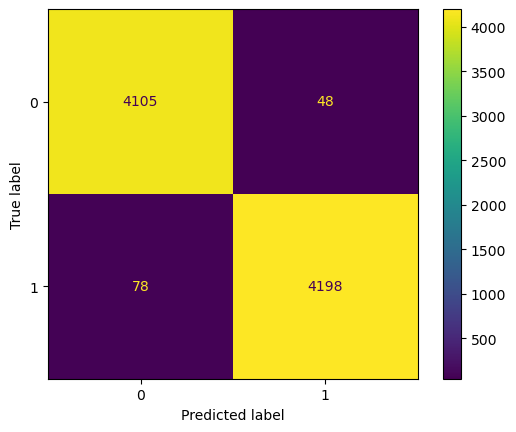

In [33]:
y_pred=nb.predict(x_test)

c_mat=confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(c_mat).plot()
accuracy_score(y_test,y_pred)

In [34]:
pickle.dump(nb,open("multinomial_nb_model.pkl", "wb"))

In [35]:
!mkdir models
!mv multinomial_nb_model.pkl models

mkdir: cannot create directory ‘models’: File exists


In [36]:
def predict(text_list):
    "Array of naive bayes model prediction for all texts in text_list"
    return nb.predict(vect.transform(np.array([preprocessing(text) for text in text_list])))

predict(["Ceci est un premier test",'Deuxième test'])

array([1, 0])

In [37]:
!pipreqsnb main.ipynb --force

/bin/bash: line 1: pipreqsnb: command not found
